In [4]:
# ============================================================
# FOOD DELIVERY TIME PREDICTION PROJECT
# Member 1: Problem Statement + Dataset Understanding
# File Used: food_delivery.csv
# Platform: Jupyter Notebook
# ============================================================
import pandas as pd
import numpy as np

df = pd.read_csv("food_delivery.csv")
print(df.head())


print("\n" + "="*60)

print("Dataset Shape (Rows, Columns):")
print(df.shape)







     ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  4607     INDORES13DEL02                   37                      4.9   
1  B379     BANGRES18DEL02                   34                      4.5   
2  5D6D     BANGRES19DEL01                   23                      4.4   
3  7A6A    COIMBRES13DEL02                   38                      4.7   
4  70A2     CHENRES12DEL01                   32                      4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude Type_of_order Type_of_vehicle  Time_taken(min)  
0     

In [ ]:
# Show all column names
print("Column Names:")
print(df.columns)

print("\n" + "="*60)

# Show data types of each column
print("Data Types:")
print(df.dtypes)

print("\n" + "="*60)

print("Dataset Information:")
print(df.info())


Column Names:
Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

Data Types:
ID                              object
Delivery_person_ID              object
Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Type_of_order                   object
Type_of_vehicle                 object
Time_taken(min)                  int64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------

In [6]:
# ------------------------------------------------------------
# Identify Target Variable
# ------------------------------------------------------------
# TARGET VARIABLE:
print("\n" + "="*60)
print("TARGET VARIABLE")
print("="*60)

target_variable = "Time_taken(min)"

print("Target Variable:")
print(target_variable)


# ------------------------------------------------------------
# Identify Input Features
# ------------------------------------------------------------


print("\n" + "="*60)
print("INPUT FEATURES")
print("="*60)

input_features = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Type_of_order",
    "Type_of_vehicle"
]

print("Input Features Used for Prediction:")

for feature in input_features:
    print("-", feature)

# ------------------------------------------------------------
# Columns to Ignore
# ------------------------------------------------------------

print("\n" + "="*60)
print("COLUMNS TO REMOVE")
print("="*60)

remove_columns = [
    "ID",
    "Delivery_person_ID"
]

for col in remove_columns:
    print("-", col)



TARGET VARIABLE
Target Variable:
Time_taken(min)

INPUT FEATURES
Input Features Used for Prediction:
- Delivery_person_Age
- Delivery_person_Ratings
- Restaurant_latitude
- Restaurant_longitude
- Delivery_location_latitude
- Delivery_location_longitude
- Type_of_order
- Type_of_vehicle

COLUMNS TO REMOVE
- ID
- Delivery_person_ID


In [11]:
# visualization for outlier checking
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [7]:

df.drop(
    ["ID", "Delivery_person_ID"],
    axis=1,
    inplace=True
)

print("\nRemoved unnecessary columns successfully")



Removed unnecessary columns successfully


In [8]:

# Check Missing Values

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(df.isnull().sum())

# Handle Missing Values

# Numerical columns -> fill using mean
# Categorical columns -> fill using mode

numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Time_taken(min)"
]

categorical_columns = [
    "Type_of_order",
    "Type_of_vehicle"
]

for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].mean())

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values handled successfully")



MISSING VALUES CHECK
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

Missing values handled successfully


In [9]:
# Remove Duplicate Rows

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

df = df.drop_duplicates()

print("Duplicates removed successfully")

Number of Duplicate Rows: 28
Duplicates removed successfully


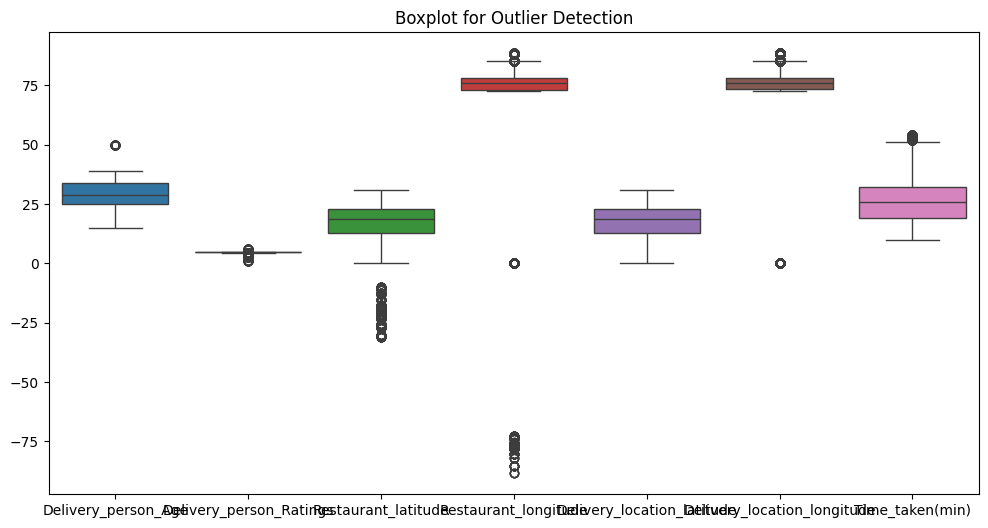


Outliers handled using IQR method


In [12]:
# Outlier Detection using Boxplot

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplot for Outlier Detection")
plt.show()

# Outlier Handling using IQR Method

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    filtered_data = data[
        (data[column] >= lower_limit) &
        (data[column] <= upper_limit)
    ]

    return filtered_data


for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

print("\nOutliers handled using IQR method")


In [14]:
# STEP 10: Encode Categorical Columns

label_encoder = LabelEncoder()

df["Type_of_order"] = label_encoder.fit_transform(
    df["Type_of_order"]
)

df["Type_of_vehicle"] = label_encoder.fit_transform(
    df["Type_of_vehicle"]
)

print("Categorical columns encoded successfully")

# Feature Scaling

features_to_scale = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]

scaler = StandardScaler()

df[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

print("Feature scaling completed successfully")

Categorical columns encoded successfully
Feature scaling completed successfully


In [15]:
#  Save Cleaned Dataset
df.to_csv(
    "food_delivery_cleaned.csv",
    index=False
)

print("\nCleaned dataset saved as:")
print("food_delivery_cleaned.csv")


Cleaned dataset saved as:
food_delivery_cleaned.csv


In [16]:
df = pd.read_csv("food_delivery_cleaned.csv")
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(33327, 9)

Column Names:
Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

Data Types:
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Type_of_order                    int64
Type_of_vehicle                  int64
Time_taken(min)                  int64
dtype: object


In [17]:
# Mean, Median, Mode
print("\n" + "="*60)
print("MEAN, MEDIAN, MODE")
print("="*60)

numerical_columns = [
    "Delivery_person_Age",
    "Delivery_person_Ratings",
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
    "Time_taken(min)"
]

for col in numerical_columns:
    print(f"\nColumn: {col}")
    print("Mean   :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode   :", df[col].mode()[0])

# Variance and Standard Deviation

for col in numerical_columns:
    print(f"\nColumn: {col}")
    print("Variance           :", df[col].var())
    print("Standard Deviation :", df[col].std())



MEAN, MEDIAN, MODE

Column: Delivery_person_Age
Mean   : 5.45800523163158e-17
Median : -0.0370809767531183
Mode   : -0.0370809767531183

Column: Delivery_person_Ratings
Mean   : -7.4621165276213e-18
Median : -0.1179989028355415
Mode   : -0.6816436548493222

Column: Restaurant_latitude
Mean   : 1.4071419737800166e-17
Median : 0.0080870468461903
Mode   : 1.516085349849616

Column: Restaurant_longitude
Mean   : -1.241909393525545e-17
Median : -0.1032910076864591
Mode   : -0.1462289871692259

Column: Delivery_location_latitude
Mean   : 2.1320332936060857e-17
Median : 0.0106883467671204
Mode   : -1.1264768328256956

Column: Delivery_location_longitude
Mean   : -1.2312492270575145e-17
Median : -0.0826489507741112
Mode   : 0.21213327837645

Column: Time_taken(min)
Mean   : 24.798511717226273
Median : 24.0
Mode   : 26

Column: Delivery_person_Age
Variance           : 1.0000300066014525
Standard Deviation : 1.0000150031881785

Column: Delivery_person_Ratings
Variance           : 1.000030006601

DISTRIBUTION ANALYSIS


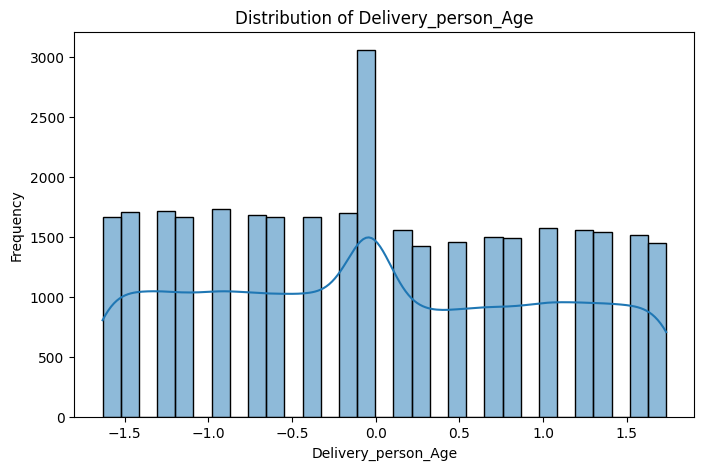

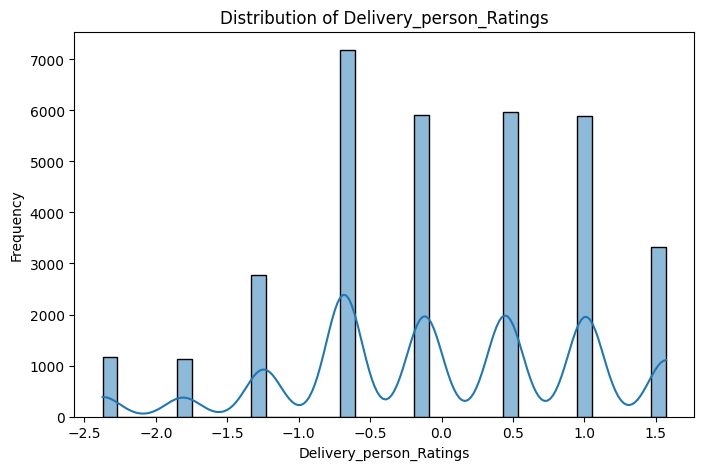

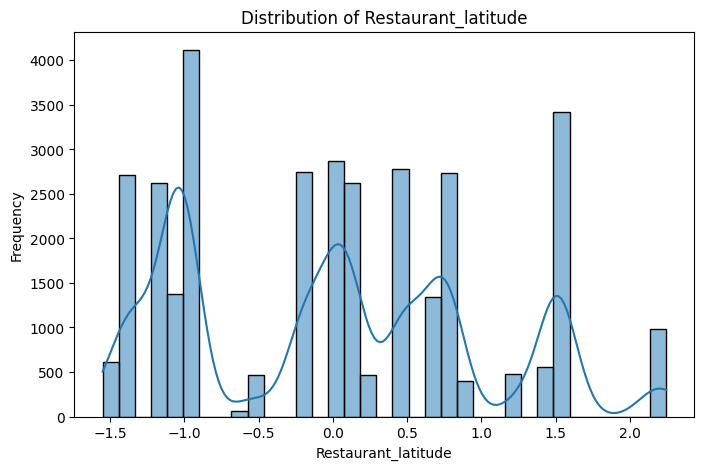

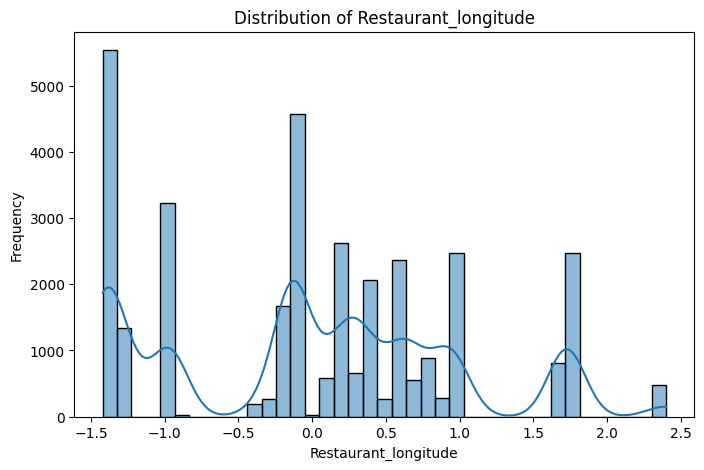

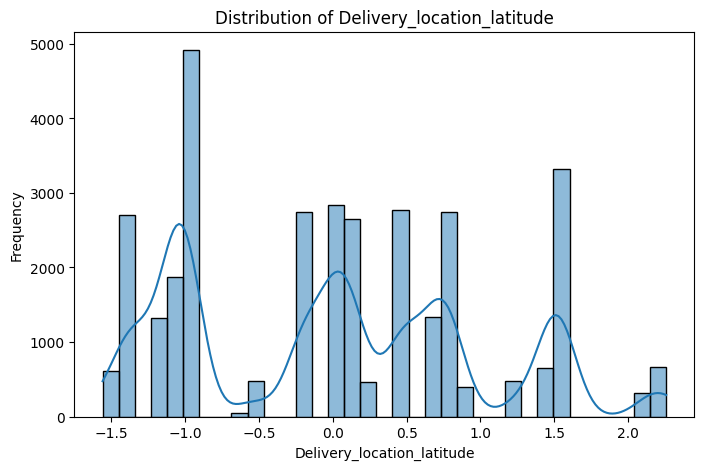

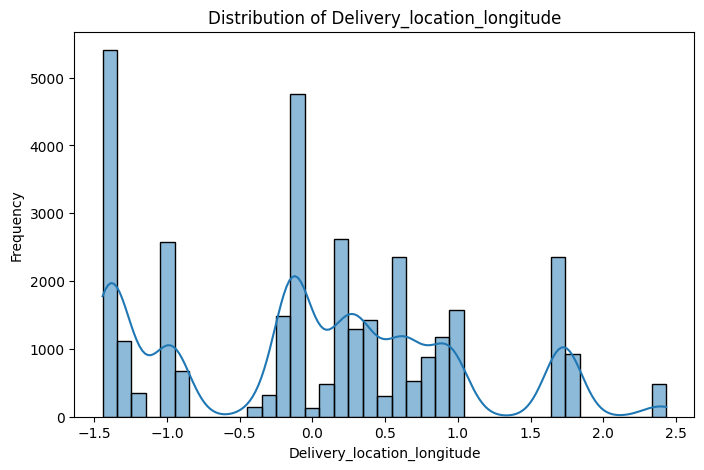

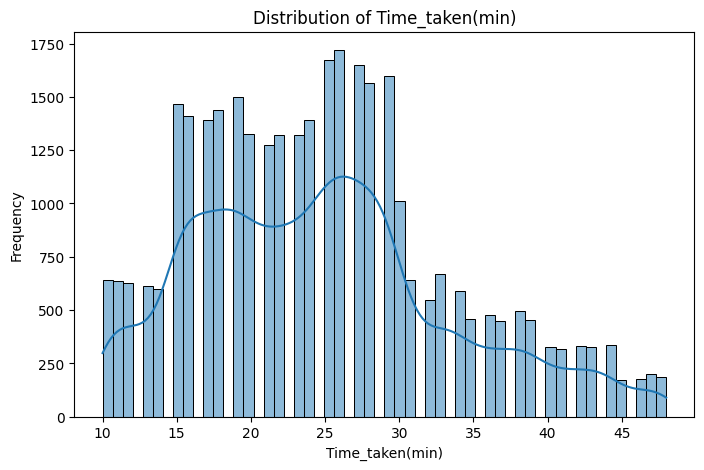

CORRELATION MATRIX
                             Delivery_person_Age  Delivery_person_Ratings  \
Delivery_person_Age                     1.000000                -0.057444   
Delivery_person_Ratings                -0.057444                 1.000000   
Restaurant_latitude                     0.001438                 0.002836   
Restaurant_longitude                    0.004007                 0.008686   
Delivery_location_latitude              0.001206                 0.002671   
Delivery_location_longitude             0.003470                 0.008304   
Type_of_order                           0.001180                -0.003839   
Type_of_vehicle                        -0.002433                 0.026763   
Time_taken(min)                         0.275248                -0.156533   

                             Restaurant_latitude  Restaurant_longitude  \
Delivery_person_Age                     0.001438              0.004007   
Delivery_person_Ratings                 0.002836              

In [18]:
# STEP 7: Distribution Analysis

print("DISTRIBUTION ANALYSIS")
print("="*60)

for col in numerical_columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Correlation Matrix

print("CORRELATION MATRIX")
print("="*60)

correlation_matrix = df.corr(numeric_only=True)

print(correlation_matrix)




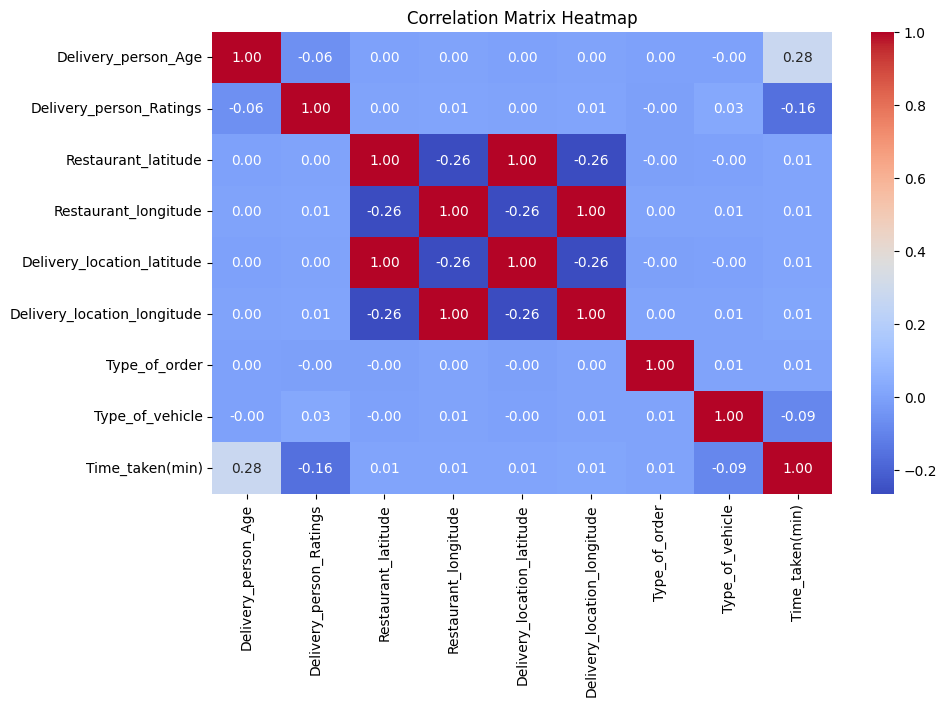

FEATURE RELATIONSHIPS


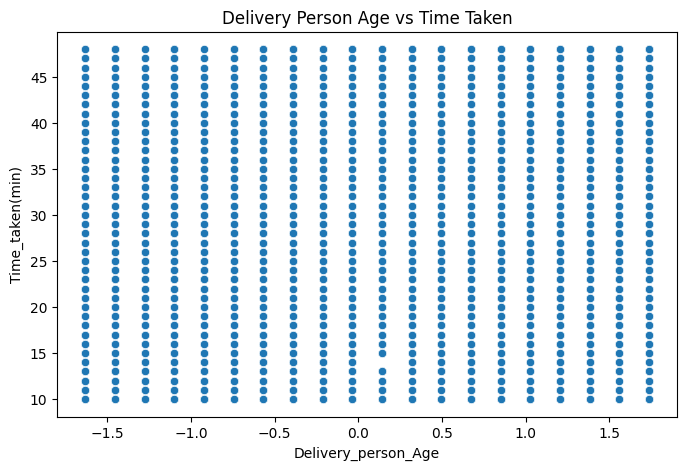

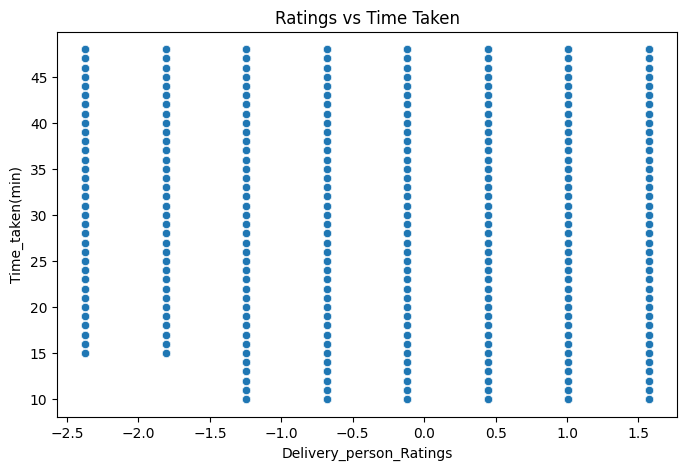

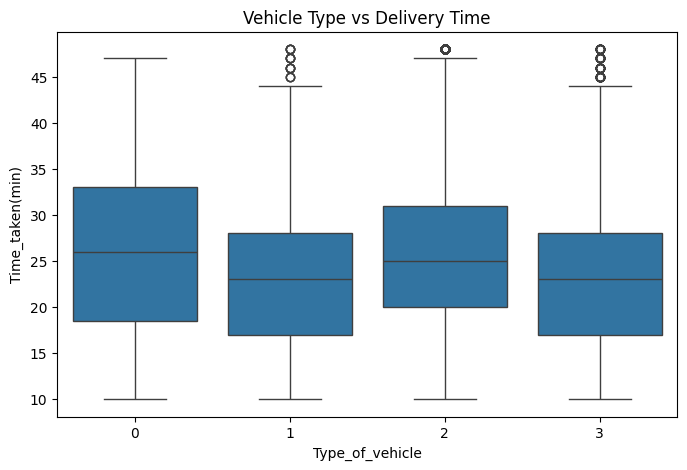

In [19]:
# Heatmap for Correlation

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")
plt.show()


# Relationship Between Features

print("FEATURE RELATIONSHIPS")
print("="*60)


# Age vs Delivery Time
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_person_Age",
    y="Time_taken(min)",
    data=df
)

plt.title("Delivery Person Age vs Time Taken")
plt.show()


# Ratings vs Delivery Time
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="Delivery_person_Ratings",
    y="Time_taken(min)",
    data=df
)

plt.title("Ratings vs Time Taken")
plt.show()


# Vehicle Type vs Delivery Time
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Type_of_vehicle",
    y="Time_taken(min)",
    data=df
)

plt.title("Vehicle Type vs Delivery Time")
plt.show()


In [20]:
# ============================================================
# Model Building (Core ML Part)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [21]:
# Features used for prediction
X = df[
    [
        "Delivery_person_Age",
        "Delivery_person_Ratings",
        "Restaurant_latitude",
        "Restaurant_longitude",
        "Delivery_location_latitude",
        "Delivery_location_longitude",
        "Type_of_order",
        "Type_of_vehicle"
    ]
]

# Target variable
y = df["Time_taken(min)"]

# 80% training data
# 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain-Test Split Completed")


Train-Test Split Completed


In [23]:
# ------------------------------------------------------------
#Linear Regression Model
# ------------------------------------------------------------

# Used for predicting delivery time

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

# ------------------------------------------------------------
# Random Forest Regressor (Optional Better Model)
# ------------------------------------------------------------

# Often gives better prediction accuracy

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")


Linear Regression Model Trained Successfully
Random Forest Model Trained Successfully


In [24]:
# Sample Prediction

sample_prediction_lr = lr_model.predict(X_test[:5])

sample_prediction_rf = rf_model.predict(X_test[:5])

print("\nSample Predictions using Linear Regression:")
print(sample_prediction_lr)

print("\nSample Predictions using Random Forest:")
print(sample_prediction_rf)




Sample Predictions using Linear Regression:
[19.52430385 30.96646202 28.51483681 23.46265903 27.77915695]

Sample Predictions using Random Forest:
[23.46 31.41 25.81 19.22 27.62]


In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

# STEP 7: Evaluation Metrics


print("\nLINEAR REGRESSION RESULTS")
print("="*40)

print("MAE  :", mean_absolute_error(y_test, lr_pred))
print("RMSE :", mean_squared_error(y_test, lr_pred) ** 0.5)
print("R2 Score :", r2_score(y_test, lr_pred))


print("\nRANDOM FOREST RESULTS")
print("="*40)

print("MAE  :", mean_absolute_error(y_test, rf_pred))
print("RMSE :", mean_squared_error(y_test, rf_pred) ** 0.5)
print("R2 Score :", r2_score(y_test, rf_pred))




LINEAR REGRESSION RESULTS
MAE  : 6.116740347107575
RMSE : 7.6453002260303755
R2 Score : 0.17449692011907492

RANDOM FOREST RESULTS
MAE  : 6.0929392332090355
RMSE : 7.704388768822775
R2 Score : 0.16168741153308763


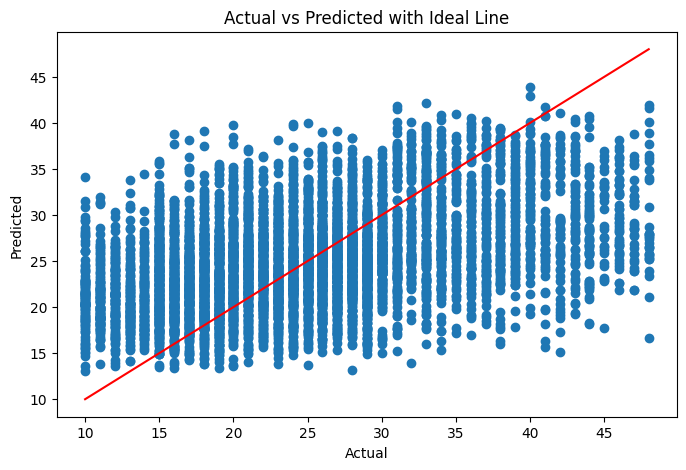


FEATURE IMPORTANCE


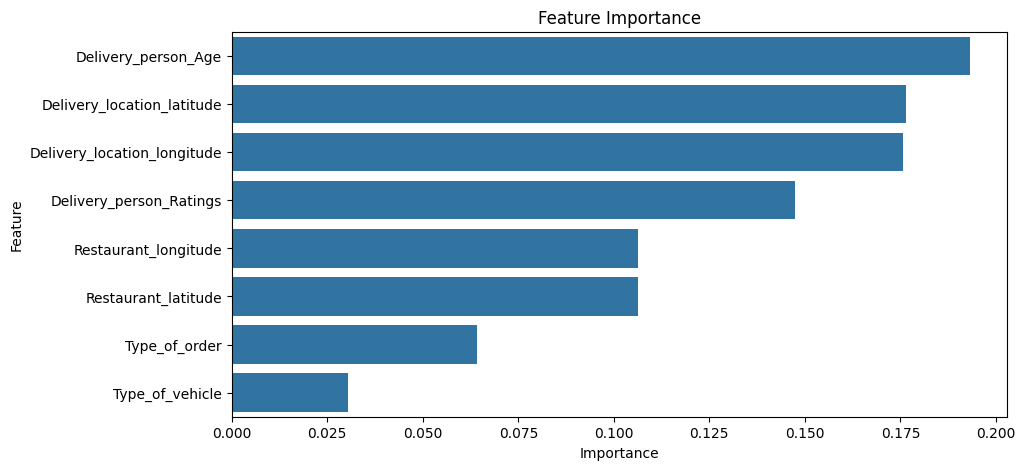

In [37]:
# Actual vs Predicted Graph

plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted with Ideal Line")
plt.show()


# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print("\nFEATURE IMPORTANCE")
print("="*40)
importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()

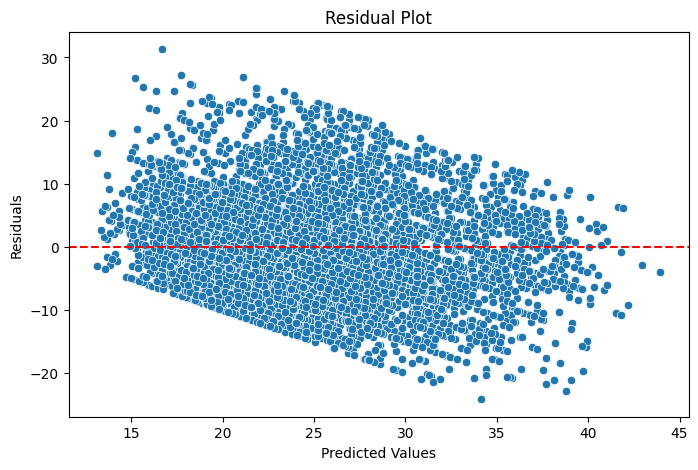

In [29]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
sns.scatterplot(x=rf_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()